# BirdCLEF+ 2026 - EDA

Purpose: inspect labels, taxonomy, audio duration, secondary labels, and soundscape annotations.  
Artifacts are written to `/kaggle/working/artifacts/eda`.


## 1. Setup


In [1]:
from pathlib import Path
import json
import os
import random
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)


class CFG:
    seed = 42
    competition_name = "birdclef-2026"
    data_root = None
    artifact_dir = Path("/kaggle/working/artifacts")


def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)


def find_data_root() -> Path:
    candidates = [
        Path("/kaggle/input/birdclef-2026"),
        Path("/kaggle/input/birdclef-2026-repack/birdclef-2026"),
        Path("/kaggle/input/birdclef-2026-repack"),
        Path("data/raw/birdclef-2026"),
    ]
    for path in candidates:
        if (path / "train.csv").exists():
            return path
    input_root = Path("/kaggle/input")
    if input_root.exists():
        matches = list(input_root.glob("**/train.csv"))
        if matches:
            return matches[0].parent
    raise FileNotFoundError("Could not find train.csv. Attach the BirdCLEF 2026 dataset.")


def read_optional_csv(path: Path) -> pd.DataFrame | None:
    return pd.read_csv(path) if path.exists() else None


seed_everything(CFG.seed)
CFG.data_root = find_data_root()
CFG.artifact_dir.mkdir(parents=True, exist_ok=True)

print(f"Data root: {CFG.data_root}")
print(f"Artifacts: {CFG.artifact_dir}")

import ast
import matplotlib.pyplot as plt
import seaborn as sns

CFG.artifact_dir = CFG.artifact_dir / "eda"
CFG.artifact_dir.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")


Data root: /kaggle/input/competitions/birdclef-2026
Artifacts: /kaggle/working/artifacts


## 2. Load Metadata


In [2]:
def parse_label_list(value) -> list[str]:
    if isinstance(value, list):
        return [str(x) for x in value]
    if pd.isna(value):
        return []
    try:
        parsed = ast.literal_eval(value)
    except (ValueError, SyntaxError):
        return []
    return [str(x) for x in parsed] if isinstance(parsed, list) else []


train = pd.read_csv(CFG.data_root / "train.csv")
taxonomy = read_optional_csv(CFG.data_root / "taxonomy.csv")
soundscape_labels = read_optional_csv(CFG.data_root / "train_soundscapes_labels.csv")
sample_submission = read_optional_csv(CFG.data_root / "sample_submission.csv")

train["filepath"] = train["filename"].map(lambda x: CFG.data_root / "train_audio" / x)
train["secondary_labels"] = train.get("secondary_labels", "[]").map(parse_label_list)

if taxonomy is not None and "primary_label" in taxonomy.columns:
    train = train.merge(taxonomy, on="primary_label", how="left", suffixes=("", "_taxonomy"))

display(train.head())
print(f"Train rows: {len(train):,}")
print(f"Primary classes: {train['primary_label'].nunique():,}")
print(f"Taxonomy rows: {0 if taxonomy is None else len(taxonomy):,}")
print(f"Soundscape label rows: {0 if soundscape_labels is None else len(soundscape_labels):,}")
print(f"Sample submission rows: {0 if sample_submission is None else len(sample_submission):,}")


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection,filepath,inat_taxon_id_taxonomy,scientific_name_taxonomy,common_name_taxonomy,class_name_taxonomy
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat,/kaggle/input/competitions/birdclef-2026/train...,1161364,Guyalna cuta,Guyalna cuta,Insecta
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat,/kaggle/input/competitions/birdclef-2026/train...,1161364,Guyalna cuta,Guyalna cuta,Insecta
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat,/kaggle/input/competitions/birdclef-2026/train...,1161364,Guyalna cuta,Guyalna cuta,Insecta
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat,/kaggle/input/competitions/birdclef-2026/train...,1161364,Guyalna cuta,Guyalna cuta,Insecta
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat,/kaggle/input/competitions/birdclef-2026/train...,1161364,Guyalna cuta,Guyalna cuta,Insecta


Train rows: 35,549
Primary classes: 206
Taxonomy rows: 234
Soundscape label rows: 1,478
Sample submission rows: 3


## 3. Label Distribution


,primary_label,recordings,share
0,rubthr1,499,0.014037
1,banana,498,0.014009
2,fepowl,497,0.013981
3,soulap1,497,0.013981
4,houspa,496,0.013953
5,coffal1,495,0.013924
6,osprey,495,0.013924
7,socfly1,494,0.013896
8,compau,493,0.013868
9,yeofly1,493,0.013868


,primary_label,recordings,share
186,22930,6,0.000169
187,22961,6,0.000169
188,1595929,5,0.000141
189,738183,5,0.000141
190,66971,5,0.000141
191,23154,5,0.000141
192,23176,4,0.000113
193,476521,3,0.000084
194,25214,3,0.000084
195,64898,3,0.000084


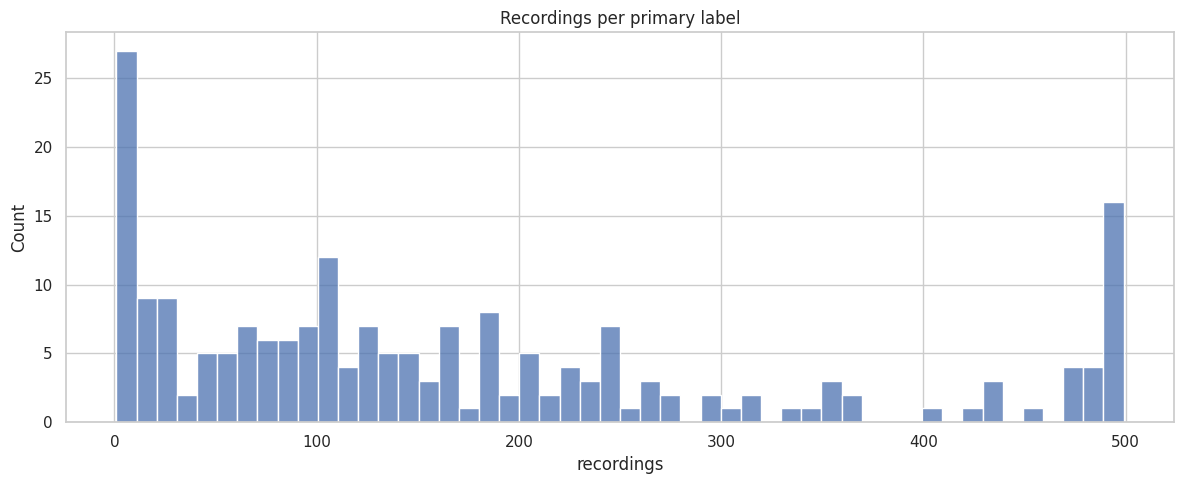

In [3]:
label_counts = (
    train["primary_label"]
    .value_counts()
    .rename_axis("primary_label")
    .reset_index(name="recordings")
)
label_counts["share"] = label_counts["recordings"] / label_counts["recordings"].sum()
label_counts.to_csv(CFG.artifact_dir / "primary_label_counts.csv", index=False)

display(label_counts.head(20))
display(label_counts.tail(20))

fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(label_counts["recordings"], bins=50, ax=ax)
ax.set_title("Recordings per primary label")
ax.set_xlabel("recordings")
fig.tight_layout()
fig.savefig(CFG.artifact_dir / "label_count_histogram.png", dpi=160)
plt.show()


## 4. Duration And Missing Files


In [4]:
if "duration" in train.columns:
    duration_summary = train["duration"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
    duration_summary.to_csv(CFG.artifact_dir / "duration_summary.csv", header=["value"])
    display(duration_summary)

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.histplot(train["duration"].clip(upper=train["duration"].quantile(0.99)), bins=60, ax=ax)
    ax.set_title("Audio duration distribution, clipped at p99")
    ax.set_xlabel("seconds")
    fig.tight_layout()
    fig.savefig(CFG.artifact_dir / "duration_histogram.png", dpi=160)
    plt.show()

missing_files = train.loc[~train["filepath"].map(Path.exists), ["filename", "filepath"]]
missing_files.to_csv(CFG.artifact_dir / "missing_audio_files.csv", index=False)
print(f"Missing audio files: {len(missing_files):,}")


Missing audio files: 0


## 5. Secondary Labels


In [5]:
secondary = train[["filename", "primary_label", "secondary_labels"]].explode("secondary_labels")
secondary = secondary.dropna(subset=["secondary_labels"])
secondary_counts = (
    secondary["secondary_labels"]
    .value_counts()
    .rename_axis("secondary_label")
    .reset_index(name="mentions")
)
secondary_counts.to_csv(CFG.artifact_dir / "secondary_label_counts.csv", index=False)
display(secondary_counts.head(20))
print(f"Rows with secondary labels: {(train['secondary_labels'].map(len) > 0).sum():,}")


,secondary_label,mentions
0,grekis,624
1,whtdov,468
2,undtin1,315
3,yecpar,226
4,rufhor2,225
5,saffin,183
6,picpig2,172
7,trokin,171
8,soulap1,154
9,grasal3,151


Rows with secondary labels: 4,372


## 6. Taxonomy And Soundscapes


In [6]:
if taxonomy is not None:
    taxonomy.to_csv(CFG.artifact_dir / "taxonomy_copy.csv", index=False)
    display(taxonomy.head())
    print(taxonomy.columns.tolist())

if soundscape_labels is not None:
    soundscape_labels.to_csv(CFG.artifact_dir / "soundscape_labels_copy.csv", index=False)
    display(soundscape_labels.head())
    print(soundscape_labels.columns.tolist())


,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1161364,1161364,Guyalna cuta,Guyalna cuta,Insecta
1,116570,116570,Caiman yacare,Southern Spectacled Caiman,Reptilia
2,1176823,1176823,Leptodactylus luctator,Wrestler Frog,Amphibia
3,1491113,1491113,Adenomera guarani,Guaraní leaf-litter frog,Amphibia
4,1595929,1595929,Lysapsus limellum,Uruguay Harlequin Frog,Amphibia


['primary_label', 'inat_taxon_id', 'scientific_name', 'common_name', 'class_name']


,filename,start,end,primary_label
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380


['filename', 'start', 'end', 'primary_label']


## 7. Artifact Manifest


In [7]:
manifest = sorted(str(path.relative_to(CFG.artifact_dir)) for path in CFG.artifact_dir.glob("*"))
(CFG.artifact_dir / "manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
manifest


['label_count_histogram.png',
 'missing_audio_files.csv',
 'primary_label_counts.csv',
 'secondary_label_counts.csv',
 'soundscape_labels_copy.csv',
 'taxonomy_copy.csv']